# New PLM generation drawing site from entropy

In [1]:
import numpy as np
import torch
import os, platform
import sys
from tqdm import tqdm

import matplotlib.pyplot as plt
from seq_utils import read_tensor_from_txt, set_seed


In [2]:
current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, '..'))
sys.path.insert(0, parent_dir)
from model import AttentionModel
from model_PCA_correlation import AttentionModel_PCA
from model_PCA_cond import ModelPCAcondJ
from dcascore import *
from utils import quickread
from attention import trainer, trainerCondJ, trainer_PCA_comp_2_model, ar_trainer # choose trainer


# back to original path (in PLM)
sys.path.pop(0)  # Removes the parent_dir from sys.path

'/Users/marzioformica/Desktop/EPFL/Master/StageLBS/PCA_gen_AI/CODE/AttentionDCA_python/src'

## Load Q,K,V

In [3]:
"""
    Load Q, K, V matrices from jdoms (after training)
"""
set_seed()
H = 64
d= 10
N = 174
n_epochs = 500
nb_PCA_comp=2
loss_type = 'without_J'
family = 'jdoms' #'jdoms_bacteria_train2'
cwd = parent_dir
Q_1 = read_tensor_from_txt( cwd +"/results/{H}_{d}_{family}_{losstype}_{n_epochs}_mod_alessandro/Q_tensor.txt".format(H=H, d=d, family=family, losstype=loss_type, n_epochs=n_epochs))
K_1 = read_tensor_from_txt( cwd +"/results/{H}_{d}_{family}_{losstype}_{n_epochs}_mod_alessandro/K_tensor.txt".format(H=H, d=d, family=family, losstype=loss_type, n_epochs=n_epochs))
V_1 = read_tensor_from_txt( cwd +"/results/{H}_{d}_{family}_{losstype}_{n_epochs}_mod_alessandro/V_tensor.txt".format(H=H, d=d, family=family, losstype=loss_type, n_epochs=n_epochs))
H,d,N=Q_1.shape
q=V_1.shape[1]

model=AttentionModel(H,d,N,q,Q=Q_1,V=V_1,K=K_1)
torch.sum(model.Q-Q_1)
device = Q_1.device
L = Q_1.shape[-1]
W=attention_heads_from_model(model,Q_1,K_1,V_1)
print(W.shape)

i_indices = torch.arange(L, device=device).unsqueeze(1)
j_indices = torch.arange(L, device=device).unsqueeze(0)
mask = (i_indices != j_indices).float().unsqueeze(0)  # shape (1, L, L)
# Mask only part without CPA
H, _, M = K_1.shape #(M=N+m)

#W[:,:,:-2] = W[:,:,:-2] * mask
W = W * mask

    
# Compute Jtens
Jtens = torch.einsum('hri,hab->abri', W, V_1)  # Shape: (q, q, L, L)
q = Jtens.shape[0]
N = Jtens.shape[2]
print(q)
print(N)
print(Jtens.shape)

torch.Size([64, 63, 63])
21
63
torch.Size([21, 21, 63, 63])


In [4]:
older_dir = os.path.abspath(os.path.join(current_dir, '..', '..', '..'))
Z,W = quickread(older_dir + '/DataAttentionDCA/jdoms/jdoms_bacteria_train2.fasta')

Total sequences read: 14502
Sequences after filtering: 14502
Sampling 100000 pairs out of 105146751 total pairs.
Mean fraction of identical positions (sampled): 0.37202728570888266
Computed theta: 0.3268577458459699


100%|██████████| 14502/14502 [00:10<00:00, 1412.85it/s]

3265.70225762244


In [5]:
def compute_empirical_freqs(Z: np.ndarray, W: np.ndarray, q: int) -> np.ndarray:
    """
    Compute empirical weighted frequencies.
    Z : ndarray of shape (N, M) with entries in [1..q]
    W : ndarray of shape (M,)
    q : alphabet size
    Returns: ndarray of shape (q, N)
    """
    N, M = Z.shape
    if W is None:
        W = np.ones(M) # divide by M at the end
        W = W / M
    else: 
        W = W / W.sum()  # Normalize weights to sum to 1
    # one-hot: (N, M, q)
    Z0 = Z - 1  # shift to 0-based indexing --- IGNORE ---
    one_hot = np.eye(q, dtype=float)[Z0]

    # Multiply weights (broadcast W along N and q)
    weighted = one_hot * W[None, :, None]  # (N, M, q)

    # Sum over sequences (axis=1), result shape (N, q)
    f = weighted.sum(axis=1).T  # (q, N)

    return f

(21, 63)
(63,)


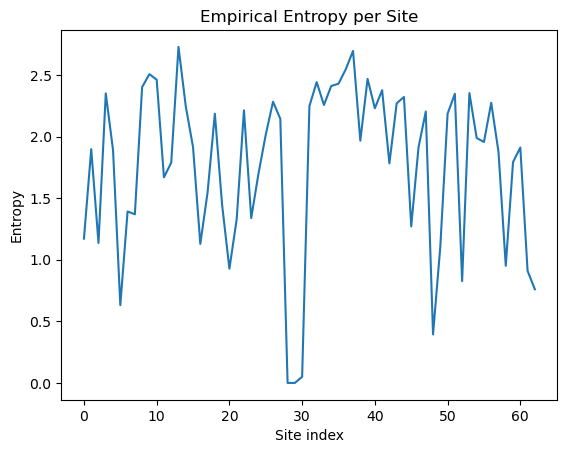

In [6]:
f_emp = compute_empirical_freqs(Z, W, q)
print(f_emp.shape)
probas = f_emp / f_emp.sum(axis=0, keepdims=True)
entropy = -np.sum(probas * np.log(probas + 1e-10), axis=0)  # Adding a small constant to avoid log(0)
print(entropy.shape)
plt.plot(entropy)
plt.xlabel('Site index')
plt.ylabel('Entropy')
plt.title('Empirical Entropy per Site')
plt.show()  

In [7]:
def site_probas(S, beta=1.0):
    """
    Compute site probabilities with temperature scaling.
    S : ndarray of shape (q, N) with empirical frequencies
    beta : inverse temperature
    Returns: ndarray of shape (q, N) with probabilities
    """
    p = np.exp(beta*S)
    probas = p / p.sum(axis=0, keepdims=True)
    return probas

p = site_probas(entropy, beta=1.0)

def beta_tanh(N_iter, N_tot, a=1, asym=False):
    # calculate beta as tanh of iteration ratio
    ratio = N_iter / N_tot
    # shift so that tanh goes from -1 to 1
    #print(a*(ratio-0.5))
    if asym: # less iterations with beta<0 
        beta = 0.5*np.tanh(a*(ratio-0.25))
    else:
        beta = 0.5*np.tanh(a*(ratio-0.5))  # scale factor to adjust steepness
    return beta

Text(0.5, 0, 'Iteration ratio')

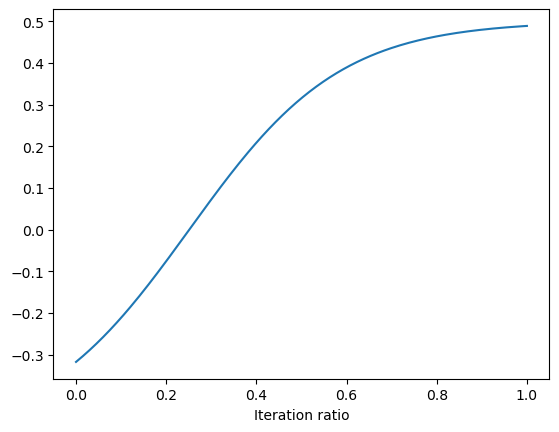

In [8]:
ratio = np.linspace(0, 1, 200)
plt.plot(ratio, beta_tanh(np.arange(200), 200, a=3, asym=True))
plt.xlabel('Iteration ratio')       

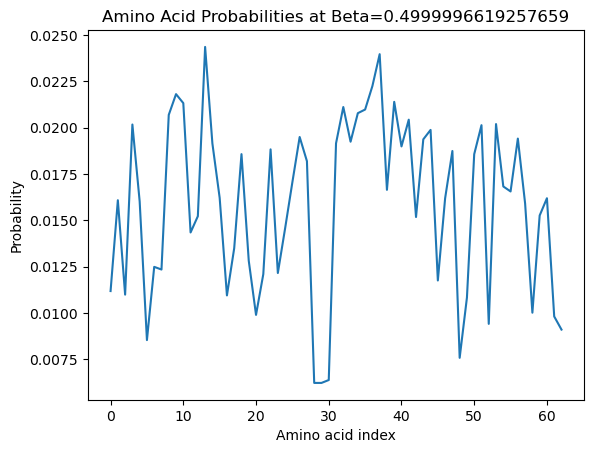

In [9]:
# test plot probas
beta = beta_tanh(199, 200, a=10, asym=True)
p_test = site_probas(entropy, beta=beta)
# plot p_test for all sites
plt.plot(p_test)
plt.xlabel('Amino acid index')
plt.ylabel('Probability')
plt.title('Amino Acid Probabilities at Beta={}'.format(beta))
plt.show()

In [68]:
def generate_plm_vec(J, N_seqs=40000, init_sequence=None, beta=1, nb_PCA_comp=0, beta_pca = 0, target_coords=np.array([]), site_selector=None):
    """
    Generate N_seqs new sequences using PLM.

    Parameters
    ----------
    J : interaction tensor
    N_seqs : int
        Number of sequences to generate
    init_sequence : array-like
        Optional initial sequence
    beta : float
        Inverse temperature
    site_selector : function(seq) -> int
        Function to select site to update.
        If None, sites are chosen uniformly at random.
    """
    gen_sequences = []
    seq = SequencePLMvec(J, init_sequence, beta=beta, nb_PCA_comp=nb_PCA_comp, target_coords=target_coords, beta_PCA=beta_pca)

    for i in tqdm(range(N_seqs)):
        if site_selector is None:
            site = np.random.randint(seq.L)  # uniform random
        else:
            beta = beta_tanh(i, N_seqs, a=3, asym=False)
            probas = site_probas(entropy, beta=beta)
            site = np.random.choice(seq.L, p=probas)  # weighted random
            #print("Selected site:", site)
            site = int(site)
        #seq.check_vectorized(site)
        seq.draw_aa(site, vec=True)
        gen_sequences.append(seq.sequence.copy())

    return np.array(gen_sequences)

In [69]:
#from plm_model import BatchSequencePLMvec

def generate_plm_last_seq(J, Nseqs=1000, steps=2000, beta=1, site_selector=None):
    """
    Generate Nseqs sequences, each evolved for 'steps' iterations.
    Returns only the final sequence for each.
    """
    L = J.shape[2]  # sequence length
    sequences = [] #np.random.randint(21, size=(Nseqs, L))  # random initialization
    SeqBatch = BatchSequencePLMvec(J, Nseqs, beta=beta)
    for i in tqdm(range(steps)):
        # pick random site per iteration (could vectorize multiple sites if desired)
        if site_selector is None:
            site = np.random.randint(L)  # uniform random
        else:
            beta_site = beta_tanh(i, steps, a=3, asym=False)
            probas = site_probas(entropy, beta=beta_site)
            site = np.random.choice(L, p=probas)  # weighted random
            #print("Selected site:", site)
            site = int(site)
        SeqBatch.draw_aa_batch(site)
        #SeqBatch.compare_draw(site)
        sequences.append(SeqBatch.get_sequences())
            #plm = BatchSequencePLMvec(J, Nseqs, beta=beta)        
        # compute PLM probabilities for all sequences at this site
        #probs = plm_site_distribution_batch_vec_full(sequences, J, site, beta)  # vectorized
        
        # vectorized sampling
        #cum_probs = np.cumsum(probs, axis=1)
        #r = np.random.rand(Nseqs)
        #sequences[:, site] = np.argmax(cum_probs >= r[:, None], axis=1)
    sequences = np.array(sequences[-1])  # return only the last sequences
    return sequences

gen_seqs_batch = generate_plm_last_seq(Jtens.cpu().numpy(), Nseqs=10000, steps=1500, beta=1, site_selector=1)
print(gen_seqs_batch.shape)

  0%|          | 0/1500 [00:00<?, ?it/s]

100%|██████████| 1500/1500 [03:45<00:00,  6.66it/s]

(10000, 63)


In [62]:
gen_seqs_batch_copy = gen_seqs_batch.copy()

In [40]:
def generate_plm_vec(J, N_seqs=40000, init_sequence=None, beta=1, nb_PCA_comp=0, beta_pca = 0, target_coords=np.array([]), site_selector=None):
    """
    Generate N_seqs new sequences using PLM.

    Parameters
    ----------
    J : interaction tensor
    N_seqs : int
        Number of sequences to generate
    init_sequence : array-like
        Optional initial sequence
    beta : float
        Inverse temperature
    site_selector : function(seq) -> int
        Function to select site to update.
        If None, sites are chosen uniformly at random.
    """
    gen_sequences = []
    seq = SequencePLMvec(J, init_sequence, beta=beta, nb_PCA_comp=nb_PCA_comp, target_coords=target_coords, beta_PCA=beta_pca)

    for i in tqdm(range(N_seqs)):
        if site_selector is None:
            site = np.random.randint(seq.L)  # uniform random
        else:   
            beta = beta_tanh(i, N_seqs, a=5, asym=True)
            probas = site_probas(entropy, beta=beta)
            site = np.random.choice(seq.L, p=probas)  # weighted random
            site = int(site)
        seq.draw_aa(site, vec=True)
        gen_sequences.append(seq.sequence.copy())
    return np.array(gen_sequences)

In [39]:
from plm_model import SequencePLMvec
generated_seqs = generate_plm_vec(Jtens.cpu().numpy(), N_seqs=1000000, beta=1, site_selector=1)

100%|██████████| 1000000/1000000 [02:16<00:00, 7323.52it/s]


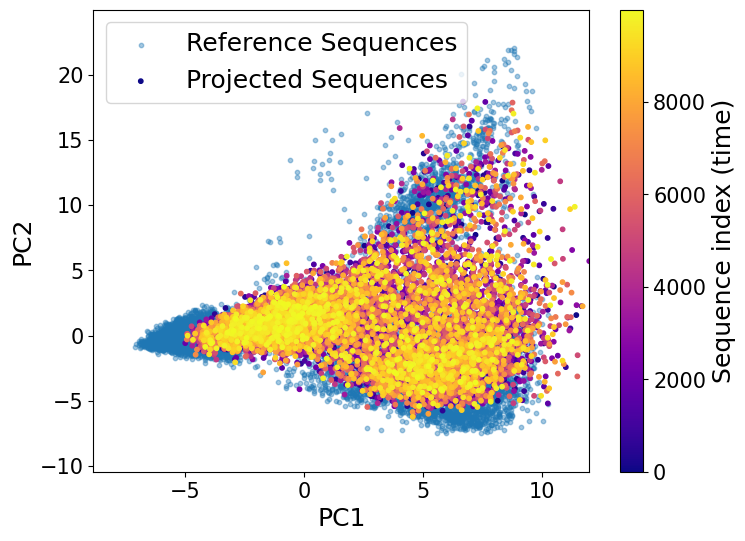

In [70]:
from PCA_func import plot_projected_pca, plot_pca_of_sequences, plot_two_pca_side_by_side, plot_projected_pca_mult, plot_projected_pca_time
#plot_projected_pca_time(Z.T,np.array(generated_seqs[::10], dtype=int))
plot_projected_pca_time(Z.T,np.array(gen_seqs_batch, dtype=int))

(21, 63)
(21, 63)


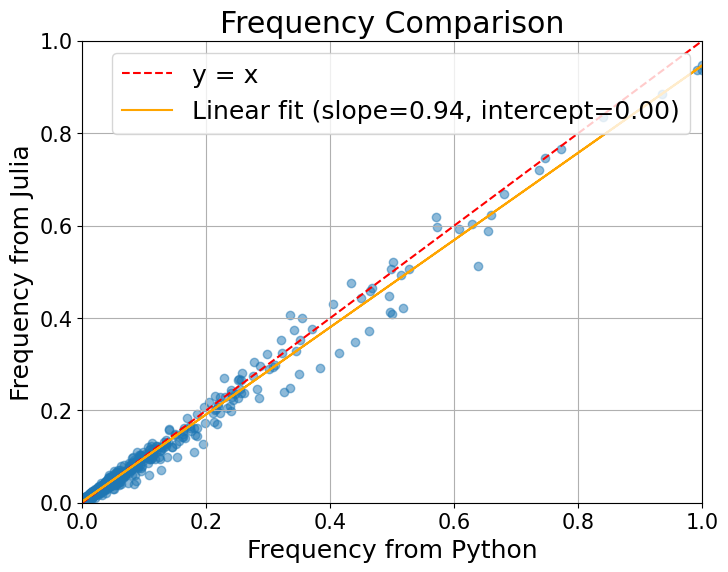

In [72]:
f_train = compute_empirical_freqs(Z, W, q=21)
f_train_flat = f_train.flatten()
print(f_train.shape)

f_gen = compute_empirical_freqs(np.array(gen_seqs_batch_copy.T, dtype=int), None, q=21)
f_gen_flat = f_gen.flatten()
print(f_gen.shape)

plt.figure(figsize=(8, 6))
plt.scatter(f_train_flat, f_gen_flat, alpha=0.5)
plt.xlabel('Frequency from Python')
plt.ylabel('Frequency from Julia')
plt.title('Frequency Comparison')

# y=x reference line
plt.plot([0, 1], [0, 1], 'r--', label='y = x')

# linear fit
m, b = np.polyfit(f_train_flat, f_gen_flat, 1)
plt.plot(f_train_flat, m*f_train_flat + b, color='orange',
         label=f'Linear fit (slope={m:.2f}, intercept={b:.2f})')

plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.show()

In [62]:
from hamming_dist import hamming_dist, energy_corr_array
initial_sequence = np.array(gen_seqs_batch[0], dtype=int)
hamming_distances = []
for seq in np.array(gen_seqs_batch,dtype=int):
    distance = hamming_dist(initial_sequence, seq)
    hamming_distances.append(distance)
hamming_distances = np.array(hamming_distances)
correlation = energy_corr_array(hamming_distances, int(len(hamming_distances)/5))

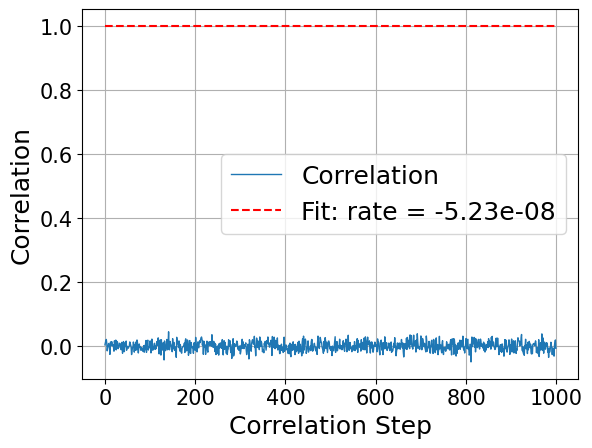

In [61]:

from scipy.stats import linregress
 
def plot_decorrelation(correlation,range,save_path=None):
    x_vals = np.arange(range)  # X values for linear fit (steps)
    y_vals = correlation[:range]  # First 1000 correlation values
    
    # Perform linear fit: y = mx + c, extract the slope (m)
    slope, intercept, r_value, p_value, std_err = linregress(x_vals, np.exp(y_vals))
    
    # Store the slope for this beta
    
    
    # Plot the correlation curve and linear fit
    plt.plot(correlation, marker='', linestyle='-', linewidth=1, label="Correlation")
    plt.plot(np.arange(len(correlation)), np.exp(slope * np.arange(len(correlation))), color='r',linestyle="--", label=f"Fit: rate = {slope:.2e}")
    plt.xlabel("Correlation Step")
    plt.ylabel("Correlation")
    plt.legend()
    plt.grid(True)
    if save_path:
        plt.savefig(save_path)
    plt.show()
    
plot_decorrelation(correlation, int(len(hamming_distances)/5), save_path=None)